# Imports

save here
/vol/projects/jnourisa

## From Ali
Processing for 3.2 M cells:
/vol/projects/CIIM/Healthy_Single_Cell_Data/scripts/processing.py

You can find some info of how they preprocessed the pbmc_ageing data here:
https://github.com/teresho4/scRNA-seq_atlas_Hs_PBMC_aging



In [14]:
%reload_ext autoreload
%autoreload 2
import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
import sys
import os
from tqdm import tqdm

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt

from src.helper_plots import exp_plots
from src.helper import major_cell_types, cell_type_mapping

# All datasets overview

In [ ]:
adata = ad.read_h5ad("/vol/projects/CIIM/Healthy_Single_Cell_Data/output/processed_data/processed_data.h5ad", backed='r')
obs = adata.obs.copy()
unique_datasets = adata.obs['orig.ident'].unique()
color_palette = sns.color_palette("tab10", len(unique_datasets))
dataset_color_mapping = {dataset: color_palette[i] for i, dataset in enumerate(unique_datasets)}


In [123]:
adata


AnnData object with n_obs × n_vars = 3265222 × 12154 backed at '/vol/projects/CIIM/Healthy_Single_Cell_Data/output/processed_data/processed_data.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden_res0_5', 'leiden_res1', 'predicted_labels', 'majority_voting', 'conf_score', 'Major_CT', 'Sub_CT', 'Celltypist_Low', 'conf_score_Low', 'over_clustering'
    var: 'features', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts', 'mean', 'std'
    uns: 'Celltypist_Low_colors', 'Major_CT_colors', 'Sub_CT_colors', 'dendrogram_Celltypist_Low', 'dendrogram_Major_CT', 'dendrogram_Sub_CT', 'leiden_res0_5', 'leiden_res1', 'log1p', 'majority_voting_colors', 'neighbors', 'over_clustering', 'pca', 'umap', 'orig.ident_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'

In [127]:
from src.helper_dataset import formatize_obs_all
obs = formatize_obs_all(adata.obs)


## Cell count of donors

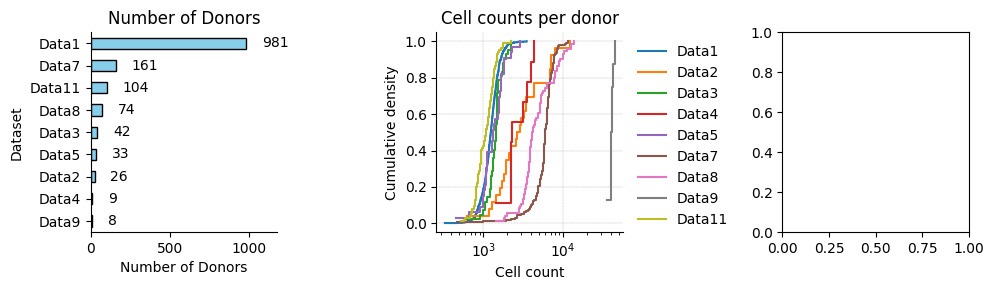

In [106]:

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# - donor counts
ax = axes[0]
donor_counts = obs.groupby('orig.ident')['donor_id'].nunique().sort_values()
donor_counts.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax)

# Add labels to the end of the bars
for index, value in enumerate(donor_counts):
    ax.text(value+100, index, f"{value}", va='center', ha='left')  # Align to the left of the bar

# Customize the axes
ax.set_ylabel("Dataset")
ax.set_xlabel("Number of Donors")
ax.set_title("Number of Donors")
ax.margins(x=0.2)
ax.spines[['top', 'right']].set_visible(False)

# - distribution of cell counts per donor
ax = axes[1]
for dataset in unique_datasets:
    obs_dataset = obs[obs['orig.ident'] == dataset].copy()
    obs_dataset['donor_id'] = obs_dataset['donor_id'].astype('str')
    counts = obs_dataset.groupby('donor_id').size().sort_values(ascending=False)
    plot_cumulative_density(counts, ax=ax, label=dataset, color=dataset_color_mapping[dataset])
    ax.set_xlabel('Cell count')
    ax.set_ylabel('Cumulative density')
    ax.set_xscale('log')
ax.set_title("Cell counts per donor")
ax.legend(loc=(1.05, 0), frameon=False)

plt.tight_layout()

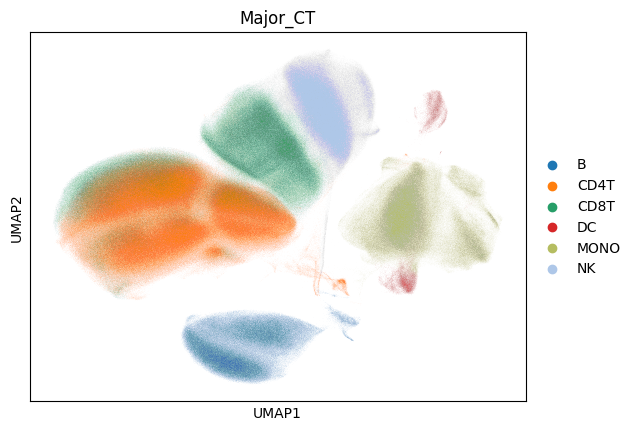

In [ ]:
sc.pl.umap(adata[adata.obs['Major_CT'].isin(major_cell_types_ali)], color='Major_CT')

# datasets overview

## Expression patterns: pseudobulked

In [2]:
adata_pbmc = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad', backed='r')
obs_pbmc = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)
adata_adata1 = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data1_CMtx.h5ad', backed='r')

In [3]:
from src.helper_dataset import formatize_obs_pbmc_ageing, formatize_obs_data1
obs_new = formatize_obs_pbmc_ageing(obs_pbmc, dataset='pbmc_ageing')
adata_pbmc.obs = adata_pbmc.obs[[]].merge(obs_new, left_index=True, right_index=True)
adata_adata1.obs = formatize_obs_data1(adata_adata1.obs, dataset='data1')


/home/jnourisa/projs/ongoing/ciim/./src/helper_dataset.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('Male','M')
/home/jnourisa/projs/ongoing/ciim/./src/helper_dataset.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('Female','F')
/home/jnourisa/projs/ongoing/ciim/./src/helper_dataset.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [4]:
def sum_by_wrapper(adata, n_cells_t=10):
    par={
        'n_cell_t': 200,
        'min_genes_per_cell': 10, 
        'max_genes_per_cell': 5000, 
        'min_cells_per_gene': 2500
    }
    adata.obs['cell_type'] = adata.obs['cell_type'].map(lambda name: cell_type_mapping.get(name,name))
    sample_size = adata.obs.groupby('age_donor', as_index=False).size()
    sample_size = sample_size[sample_size['size']>par['n_cell_t']]

    adata.obs = adata.obs[adata.obs.age_donor.isin(sample_size.age_donor)]
    adata = basic_qc(adata, min_genes_per_cell=par['min_genes_per_cell'], max_genes_per_cell=par['max_genes_per_cell'], min_cells_per_gene=par['min_cells_per_gene'])
    sys.path.insert(0, '../')
    from task_grn_inference.src.process_data.perturbation.opsca.script import sum_by
    adata.obs['sum_by'] = '_' + adata.obs['cell_type'].astype(str) + '_' + adata.obs['donor_id'].astype(str)
    adata.obs['sum_by'] = adata.obs['sum_by'].astype('category')
    adata_bulk = sum_by(adata, 'sum_by', unique_mapping=False)
    cell_count_df = adata.obs.groupby('sum_by').size().reset_index(name='cell_count')
    adata_bulk.obs = adata_bulk.obs.merge(cell_count_df, on='sum_by')
    adata_bulk = adata_bulk[adata_bulk.obs['cell_count']>n_cells_t]
    return adata_bulk
adata_pbmc = sum_by_wrapper(adata_pbmc.to_memory())
adata_adata1 = sum_by_wrapper(adata_adata1.to_memory())

shape before  (1916367, 36601)
shape after  (1916367, 16003)


/vol/tmp/users/jnourisa/ipykernel_2382431/3960274418.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sum_by'] = '_' + adata.obs['cell_type'].astype(str) + '_' + adata.obs['donor_id'].astype(str)


shape before  (1248980, 24281)
shape after  (1248940, 12273)


/vol/tmp/users/jnourisa/ipykernel_2382431/3960274418.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sum_by'] = '_' + adata.obs['cell_type'].astype(str) + '_' + adata.obs['donor_id'].astype(str)


In [5]:
adata_all_bulk = ad.concat([adata_pbmc, adata_adata1])

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
adata_all_bulk.obs_names_make_unique()

In [7]:
def analyse_umap(adata):
    # adata = adata[adata.obs['cell_type'].isin(major_cell_types), :]
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    # sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    sc.pp.pca(adata, use_highly_variable=False)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    return adata
adata_all_bulk = analyse_umap(adata_all_bulk)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


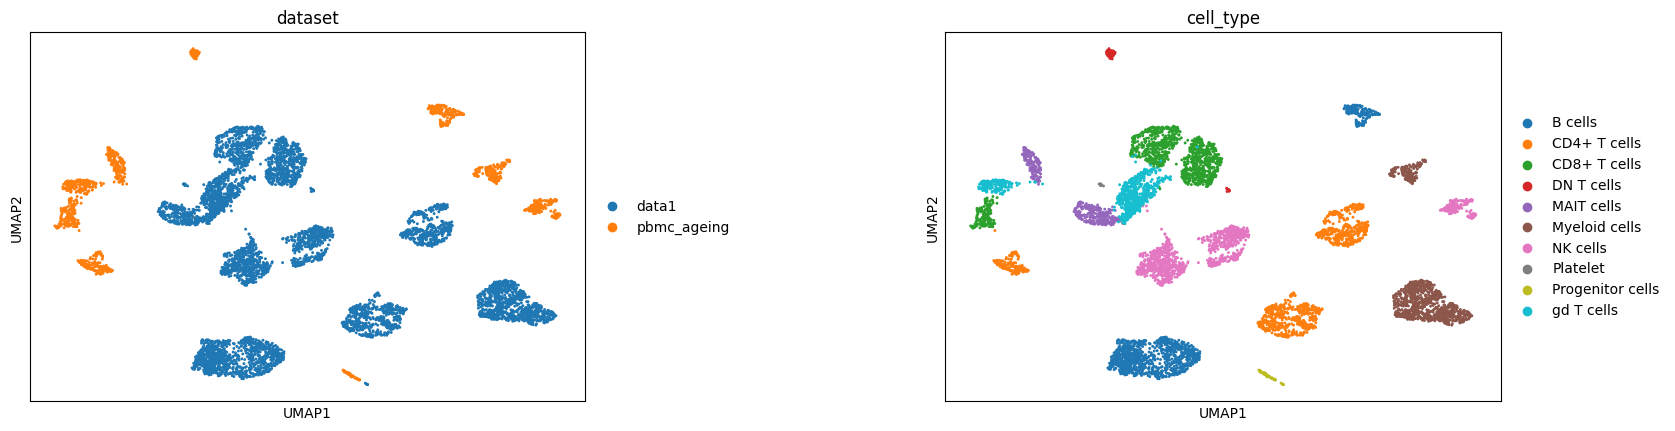

In [8]:
sc.pl.umap(adata_all_bulk, color=['dataset', 'cell_type'], wspace=.5)

In [9]:
adata_all_bulk.write('input/adata_all_bulk.h5ad')

In [ ]:
aa

## Cell count overview

In [10]:
obs_pbmc = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)
obs_adata1 = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data1_CMtx.h5ad', backed='r').obs

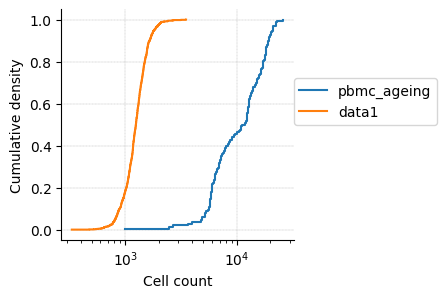

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)


for i, (dataset, counts) in enumerate(zip(['pbmc_ageing', 'data1'], [obs_pbmc.groupby('Donor_id').size(), obs_adata1.groupby('donor_id').size()])):
    # ax.hist( ], bins=100)
    plot_cumulative_density(counts, ax=ax, label=dataset)
    ax.set_xlabel('Cell count')
    ax.set_ylabel('Cumulative density')
    ax.set_xscale('log')

plt.legend(loc=(1, .5))
    


# Process raw dataset

In [12]:
# python src/helper_dataset.py

In [13]:
# exp_plots(obs.groupby('age_group'), cell_type=True)

# Exp stats of data

In [14]:
# for dataset in ['pbmc_ageing_downsample','data1', 'pbmc_ageing']:
n_cells = adata.obs.groupby(['age_group', 'cell_type', 'batch_group']).size().reset_index(name='n_cells')
sns.catplot(n_cells, x='cell_type', y='n_cells', col='age_group', hue='batch_group', kind='bar')

NameError: name 'adata' is not defined

# UMAP

In [3]:
from src.helper import  major_cell_types


In [13]:
dataset = 'pbmc_ageing'

In [14]:
if True:
    adata = ad.read_h5ad(f'input/{dataset}.h5ad')
    adata = adata[adata.obs['cell_type'].isin(major_cell_types), :]
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write(f'input/{dataset}_umap.h5ad')
else:
    adata = ad.read_h5ad(f'input/{dataset}_umap.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


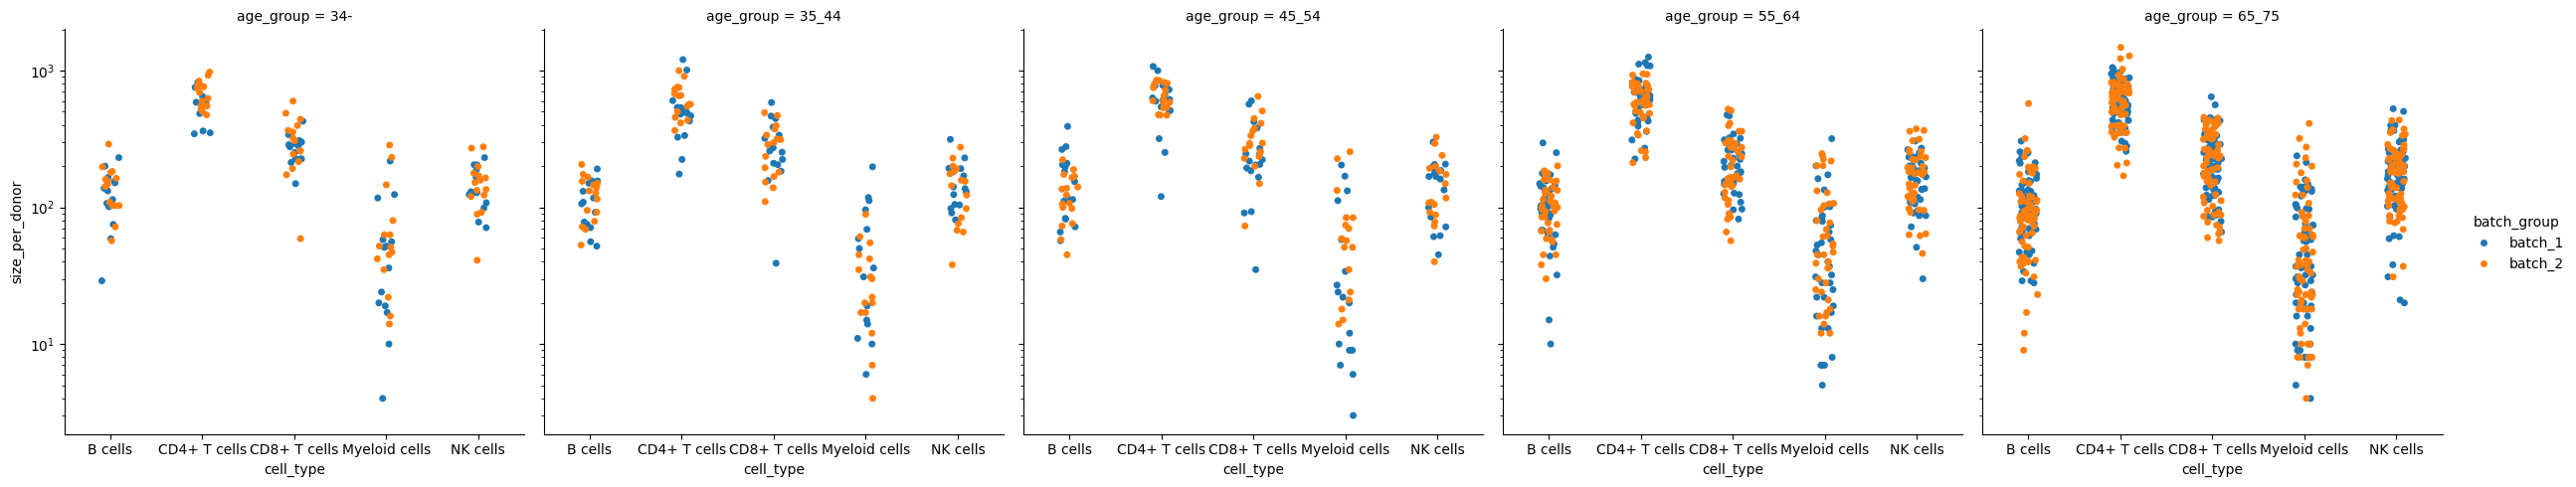

In [25]:
size_per_donor = adata.obs.groupby(['age_group', 'cell_type', 'batch_group','donor_id']).size().reset_index(name='size_per_donor')
g= sns.catplot(size_per_donor, x='cell_type', y='size_per_donor', col='age_group', hue='batch_group', kind='strip')
g.set(yscale="log")

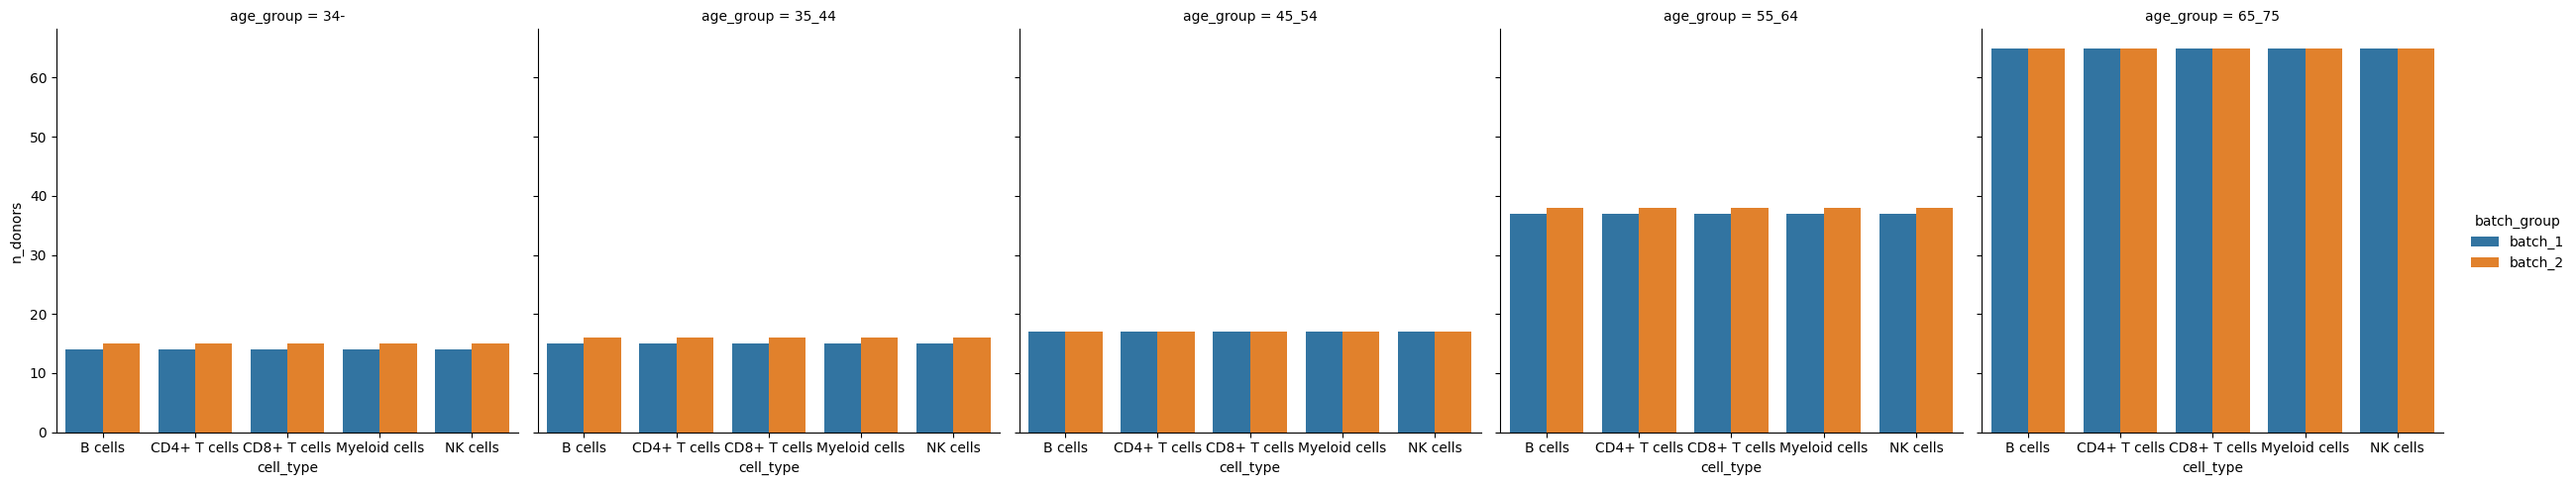

In [26]:
n_donors = adata.obs.groupby(['age_group', 'cell_type', 'batch_group'])['donor_id'].nunique().reset_index(name='n_donors')
sns.catplot(n_donors, x='cell_type', y='n_donors', col='age_group', hue='batch_group', kind='bar')

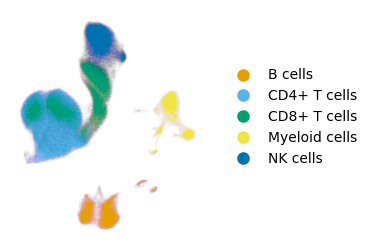

In [12]:
from src.helper import cell_type_palette

def plot_umap(adata, color='', palette=None, ax=None, X_label='X_umap', on_data=False,
              bbox_to_anchor=None, legend=True, legend_title='', **kwrds):
    latent = adata.obsm[X_label]
    var_unique_sorted = sorted(adata.obs[color].unique())
    legend_handles = []
    
    for i_group, group in enumerate(var_unique_sorted):
        mask = adata.obs[color] == group
        sub_data = latent[mask]
        if palette is None:
            c = None 
        else:
            c = palette[group]
        # Plot scatter points
        scatter = ax.scatter(sub_data[:, 0], sub_data[:, 1], label=group, c=c, **kwrds)
        if palette is None:
            solid_color = scatter.get_facecolor()[0]
        else:
            solid_color = c
        # plot legend
        legend_handles.append(plt.Line2D([0], [0], linestyle='none', marker='o', markersize=8, color=solid_color))
        if on_data:
            mean_x = np.mean(sub_data[:, 0])
            mean_y = np.mean(sub_data[:, 1])
            ax.text(mean_x, mean_y, group, fontsize=9, ha='center', va='top', color='black', weight='bold')
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    if legend and not on_data:
        legend = ax.legend(handles=legend_handles, labels=var_unique_sorted, loc=(1.1,.3), 
                           bbox_to_anchor=bbox_to_anchor, frameon=False, title=legend_title, 
                           title_fontproperties={'weight': 'bold', 'size': 9})
        legend.get_title().set_ha('left')
        legend._legend_box.align = "left" 
    

# Example usage
fig, ax = plt.subplots(1, 1, figsize=(2.5, 3))
plot_umap(adata, color='cell_type', ax=ax, s=.4, alpha=0.005, palette=cell_type_palette)  
# plot_umap(adata[adata.obs['batch_group']=='batch_2'], color='batch_group', ax=ax, s=1, alpha=0.3)  
# plot_umap(adata, color='donor_id', ax=ax, s=1, alpha=0.3)  
plt.savefig(f'output/figs/umap_{dataset}.png', dpi=300, bbox_inches='tight')


In [2]:
adata = ad.read_h5ad('input/data1_male.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
adata

AnnData object with n_obs × n_vars = 0 × 0
    obs: 'batch_group', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group', 'batch', 'dataset'
    var: 'features'